# Unsupervised Learning:3-6 clusters|K-Means |EDA

https://www.kaggle.com/code/tanmay111999/unsupervised-learning-3-6-clusters-k-means-eda/notebook

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D

In [82]:
data = pd.read_csv('/content/drive/MyDrive/data/Mall_Customers.csv')
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [83]:
data.shape

(200, 5)

In [84]:
data.columns

Index(['CustomerID', 'Gender', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [85]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


<Axes: >

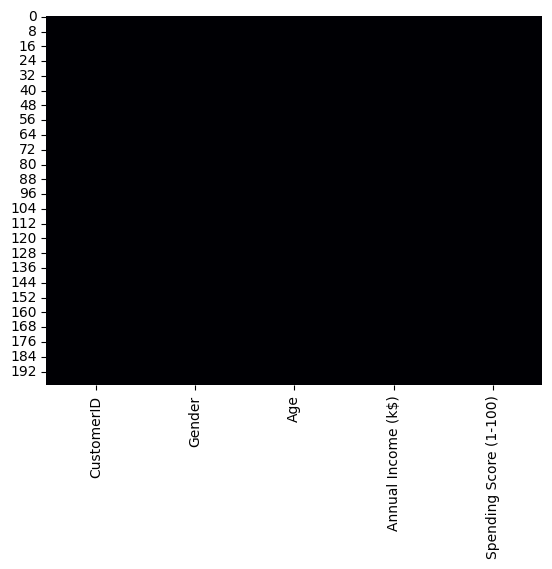

In [86]:
sns.heatmap(data.isnull(), cmap='magma', cbar=False)

-> No null values present in the data

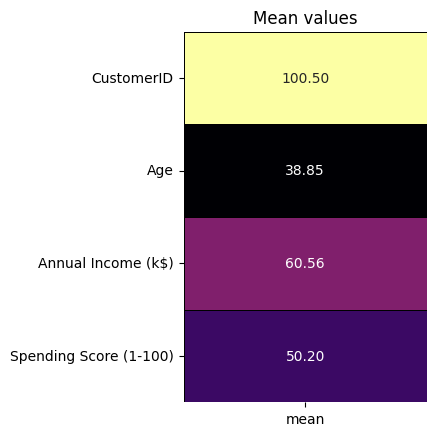

In [87]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))

sns.heatmap(data.describe().T[['mean']], cmap='inferno', annot=True, fmt='.2f', linecolor='black', linewidths=0.4, cbar=False, ax=ax);
ax.set_title('Mean values');

fig.tight_layout(pad=3)

### Exploratory Data Analysis

Dividing features into Numerical and Categorical

In [88]:
col = list(data.columns)
categorical_features = []
numerical_features = []

for i in col:
  if len(data[i].unique())>6:
    numerical_features.append(i)
  else:
    categorical_features.append(i)

print('Numerical Features: ', *numerical_features)
print('Categorical Features: ', *categorical_features)

Numerical Features:  CustomerID Age Annual Income (k$) Spending Score (1-100)
Categorical Features:  Gender


In [89]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df1 = data.copy(deep = True)

df1['Gender'] = le.fit_transform(df1['Gender'])

print('Label Encoder Transformation')
print(df1['Gender'].unique(), ' = ', le.inverse_transform(df1['Gender'].unique()))

Label Encoder Transformation
[1 0]  =  ['Male' 'Female']


Distribution of Categorical and Numerical Features

/tmp/ipykernel_4323/2299061485.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: 

The `bw` parameter is deprecated in favor of `bw_method` and `bw_adjust`.
Setting `bw_method=1`, but please see the docs for the new parameters
and update your code. This will become an error in seaborn v0.14.0.

  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/tmp/ipykernel_4323/2299061485.py:11: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to 

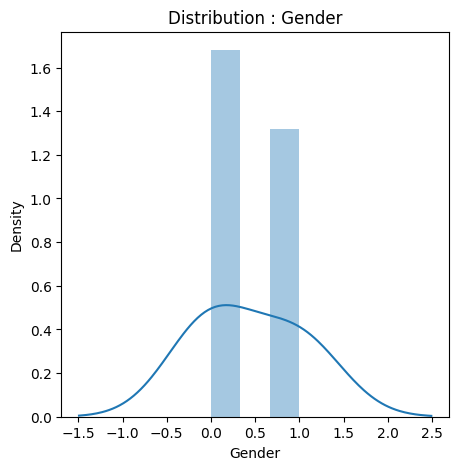

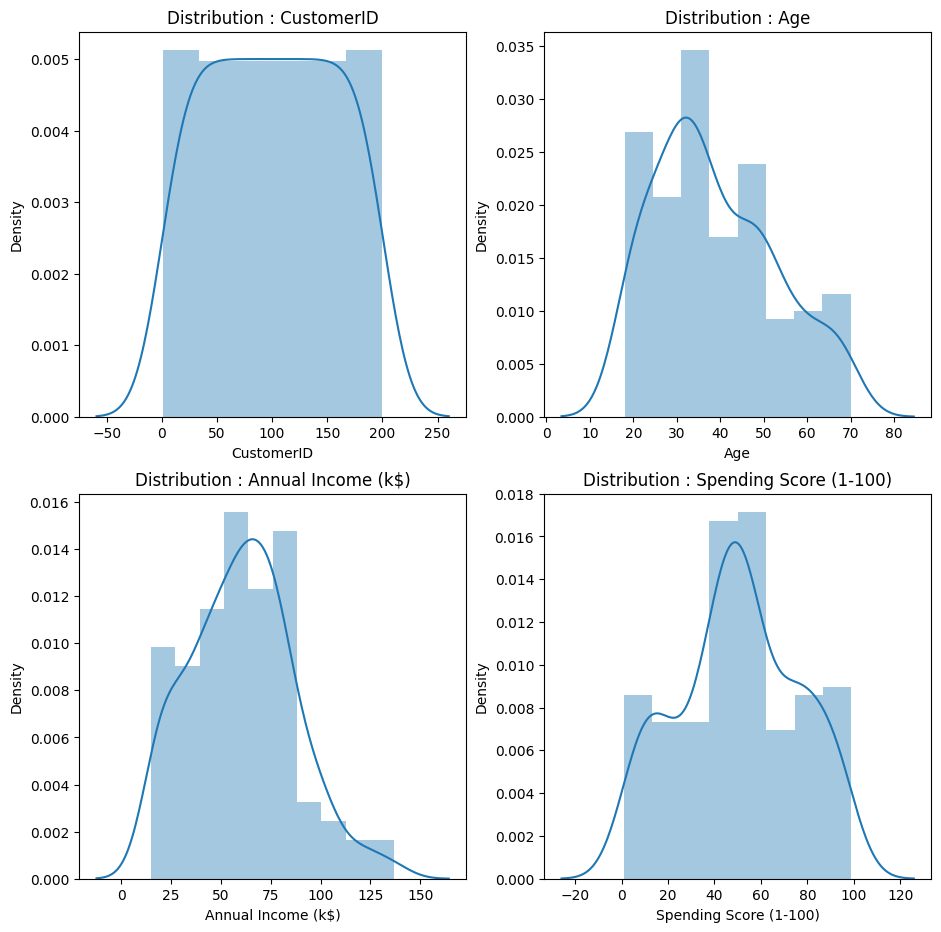

In [90]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(5,5))
for i in range(len(categorical_features)):
  plt.subplot(1,1,i+1)
  sns.distplot(df1[categorical_features[i]],kde_kws = {'bw' : 1});
  title = 'Distribution : ' + categorical_features[i]
  plt.title(title)

fig, ax = plt.subplots(nrows = 2,ncols = 2,figsize = (11,11))
for i in range(len(numerical_features)):
    plt.subplot(2,2,i+1)
    sns.distplot(data[numerical_features[i]],)
    title = 'Distribution : ' + numerical_features[i]
    plt.title(title)
plt.show()

In [91]:
numerical_features.remove('CustomerID')

/tmp/ipykernel_4323/1807537995.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Gender',data = df1,palette = colors,edgecolor = 'black', ax=axes[1]);
/tmp/ipykernel_4323/1807537995.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Female','Male'])


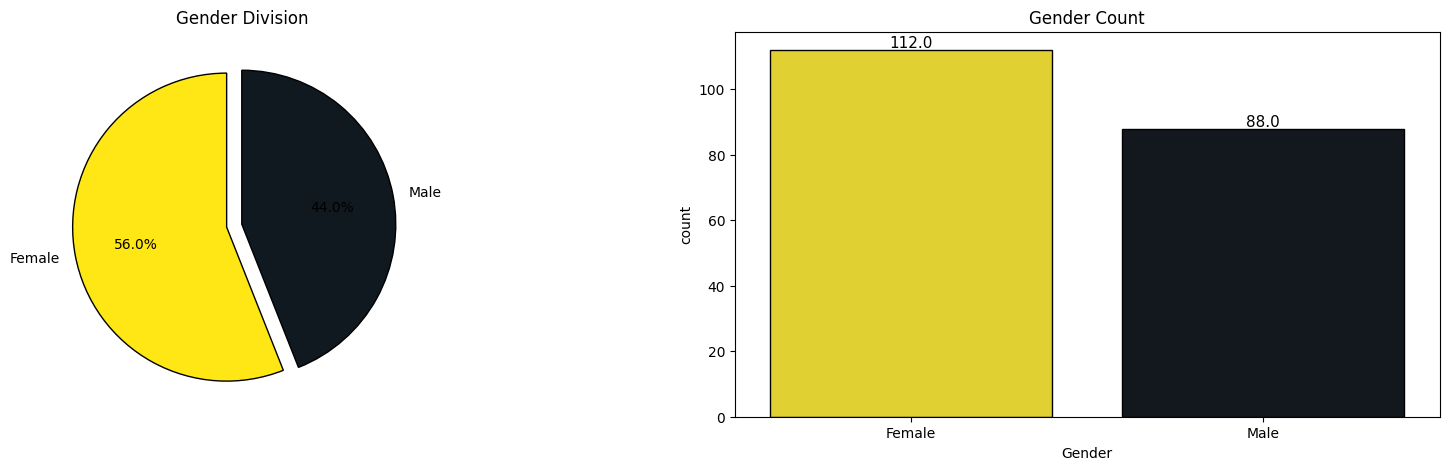

In [92]:
l = list(data['Gender'].value_counts())
circle = [l[0] / len(l) * 100, l[1] / len(l) * 100]
colors = ['#FEE715','#101820']

fig, axes = plt.subplots(nrows = 1,ncols = 2,figsize = (20,5))

# Plot on the first axis (axes[0])
axes[0].pie(circle,labels = ['Female','Male'],autopct='%1.1f%%',startangle = 90,explode = (0.1,0),colors = colors,
       wedgeprops = {'edgecolor' : 'black','linewidth': 1,'antialiased' : True})
axes[0].set_title('Gender Division');

# Plot on the second axis (axes[1])
sns.countplot(x='Gender',data = df1,palette = colors,edgecolor = 'black', ax=axes[1]);
for rect in axes[1].patches:
    axes[1].text(rect.get_x() + rect.get_width() / 2, rect.get_height() + 0.75, rect.get_height(), horizontalalignment='center', fontsize = 11)
axes[1].set_title('Gender Count')
axes[1].set_xticklabels(['Female','Male'])

plt.show()

Numerical Features vs Categorical Features

/tmp/ipykernel_4323/3178044531.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
/tmp/ipykernel_4323/3178044531.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Female','Male'])
/tmp/ipykernel_4323/3178044531.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
/tmp/ipykernel_4323/3178044531.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xt

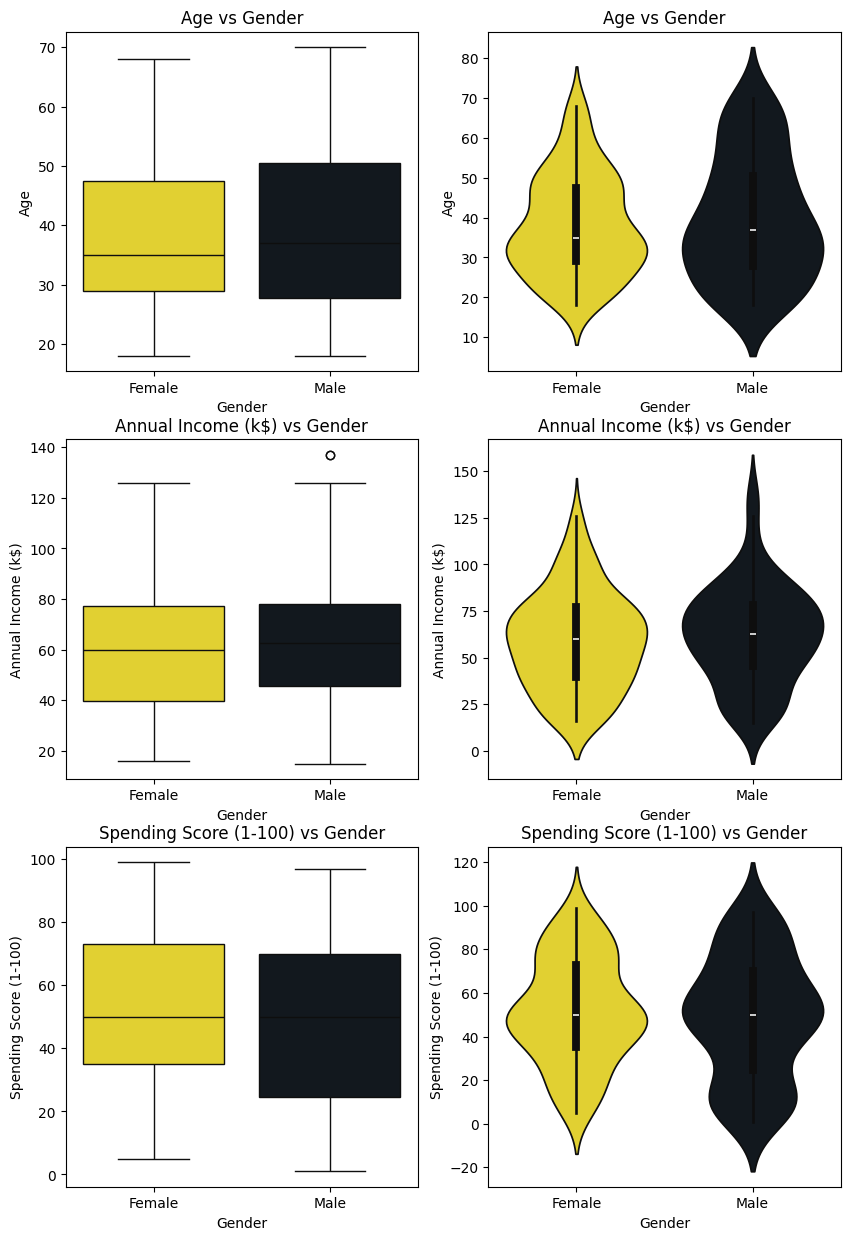

In [93]:
fig = plt.subplots(nrows = 3,ncols = 2,figsize = (10,15))
for i in range(len(numerical_features)):
    plt.subplot(3,2, (i * 2)  + 1)
    ax = sns.boxplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
    ax.set_xticklabels(['Female','Male'])
    title = numerical_features[i] + ' vs Gender'
    plt.title(title)

    plt.subplot(3,2,(i * 2) + 2)
    ax = sns.violinplot(x = 'Gender',y = numerical_features[i],palette = colors,data = df1)
    ax.set_xticklabels(['Female','Male'])
    title = numerical_features[i] + ' vs Gender'
    plt.title(title)

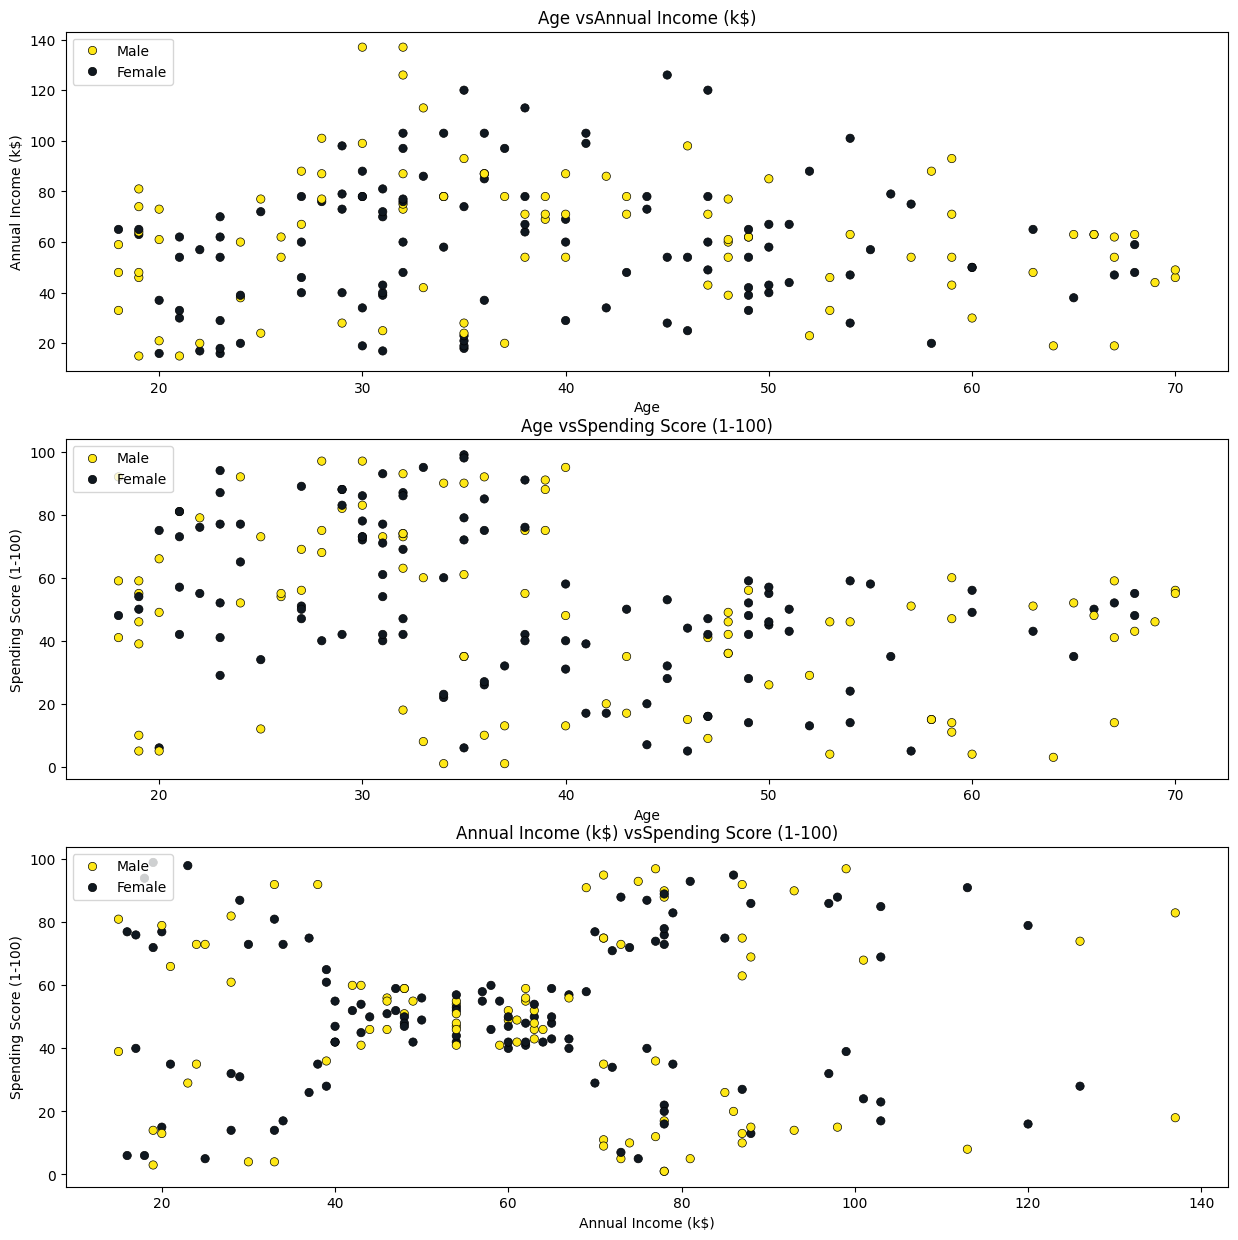

In [94]:
a = 0
fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15,15))
for i in range(len(numerical_features)-1):
  for j in range(len(numerical_features)):
    if i != j and j>i:
      a +=1
      plt.subplot(3,1,a)
      sns.scatterplot(x=numerical_features[i], y=numerical_features[j], data=data, hue = 'Gender', palette=colors, edgecolor='black')
      plt.legend(loc='upper left')
      title = numerical_features[i]+' vs'+ numerical_features[j]
      plt.title(title)

### Summary of EDA

- For the above mall data, female customers are more than male customers. Gender data is pretty much evenly distributed w.r.t other features.
- Mall customers can be divided by their Age groups :\
20 - 30 \
30 - 40 \
40 - 70.
- Median Annual Income (k$) of both the genders is about 60k. It displays 3 groups of values :\
0 - 40k\
40 - 70k\
70 - 140k.
- Spending Score (1-100) of female is higher than male customers. It can also divide the customers into 3 groups :\
0 - 40\
40 - 60\
60 - 100
- Using the combination of the above values, Mall Customers can be segmented and thus resulting in specific catering of them.

### Feature Engineering

- Correlation Matrix

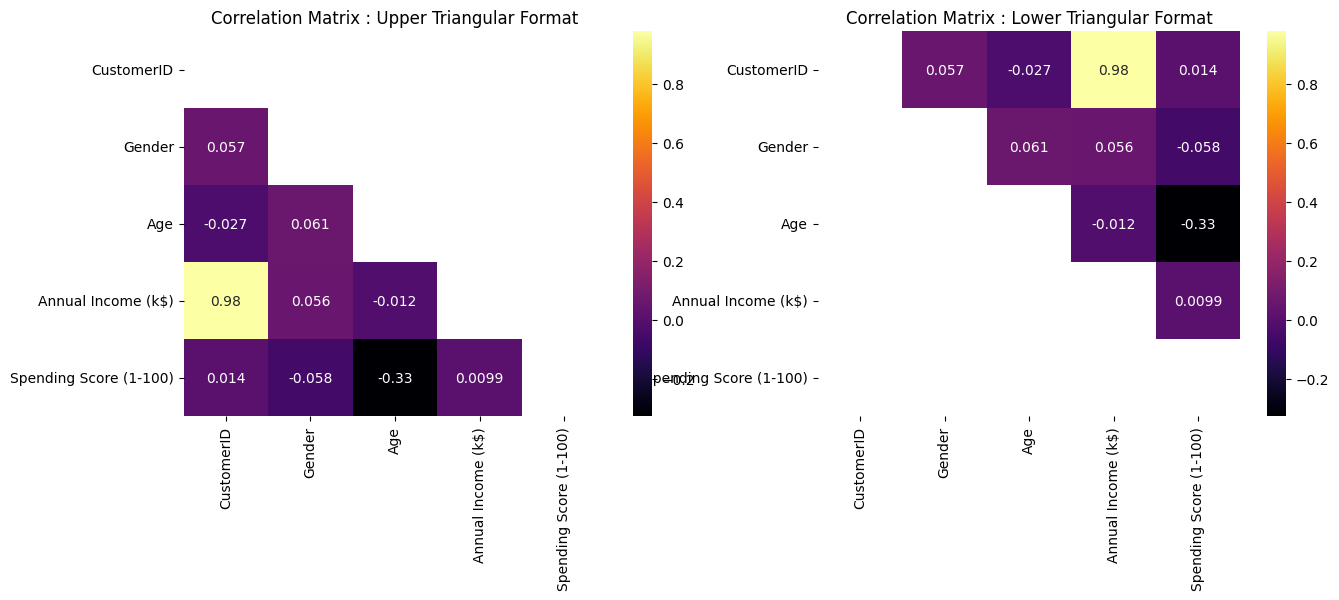

In [95]:
ut = np.triu(df1.corr())
lt = np.tril(df1.corr())

fig,ax = plt.subplots(nrows = 1, ncols = 2,figsize = (15,5))
plt.subplot(1,2,1)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = ut);
plt.title('Correlation Matrix : Upper Triangular Format');

plt.subplot(1,2,2)
sns.heatmap(df1.corr(),cmap = 'inferno',annot = True,cbar = 'True',mask = lt);
plt.title('Correlation Matrix : Lower Triangular Format');

df1.drop(columns = 'CustomerID',inplace = True)

Data Scaling

1) Normalization
2) Standardization

In [96]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
mms = MinMaxScaler()
ss = StandardScaler()

df2 = df1.copy(deep=True)

df2['Age'] = mms.fit_transform(df2[['Age']])
df2['Annual Income (k$)'] = mms.fit_transform(df2[['Annual Income (k$)']]) # Corrected column name
df2['Spending Score (1-100)'] = mms.fit_transform(df2[['Spending Score (1-100)']]) # Corrected column name

### Modeling

In [97]:
#dropping categorical feature
df1.drop(columns='Gender', inplace=True)
df2.drop(columns='Gender', inplace=True)

In [98]:
m1 = df1[['Age', 'Annual Income (k$)']].values #Original Dataset
m2 = df2[['Age', 'Annual Income (k$)']].values #Normalized Dataset

Original Dataset

Elbow Method & Silhouette Score Method

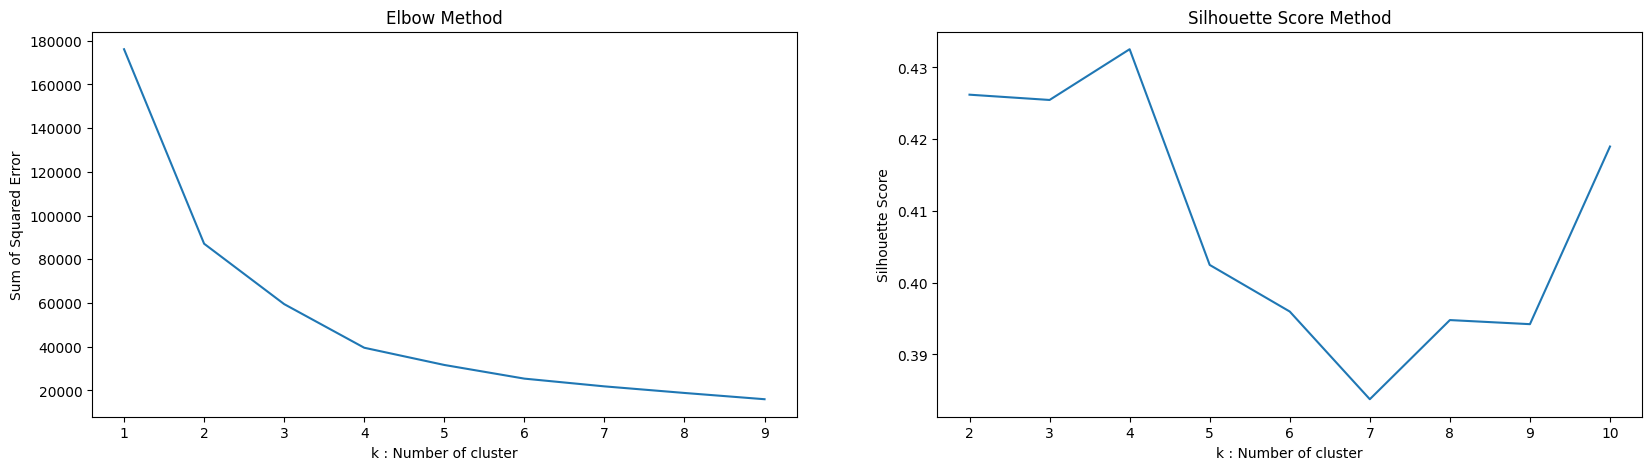

In [99]:
sse = {};sil = [];kmax = 10
fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000, n_init=10).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()), ax=axes[0]);
axes[0].set_title('Elbow Method')
axes[0].set_xlabel('k : Number of cluster')
axes[0].set_ylabel('Sum of Squared Error')

# Silhouette Score Method
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k, n_init=10).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil, ax=axes[1]);
axes[1].set_title('Silhouette Score Method')
axes[1].set_xlabel('k : Number of cluster')
axes[1].set_ylabel('Silhouette Score')
plt.show()

위의 2가지 방법의 결과로 봤을때, k: clusters=4

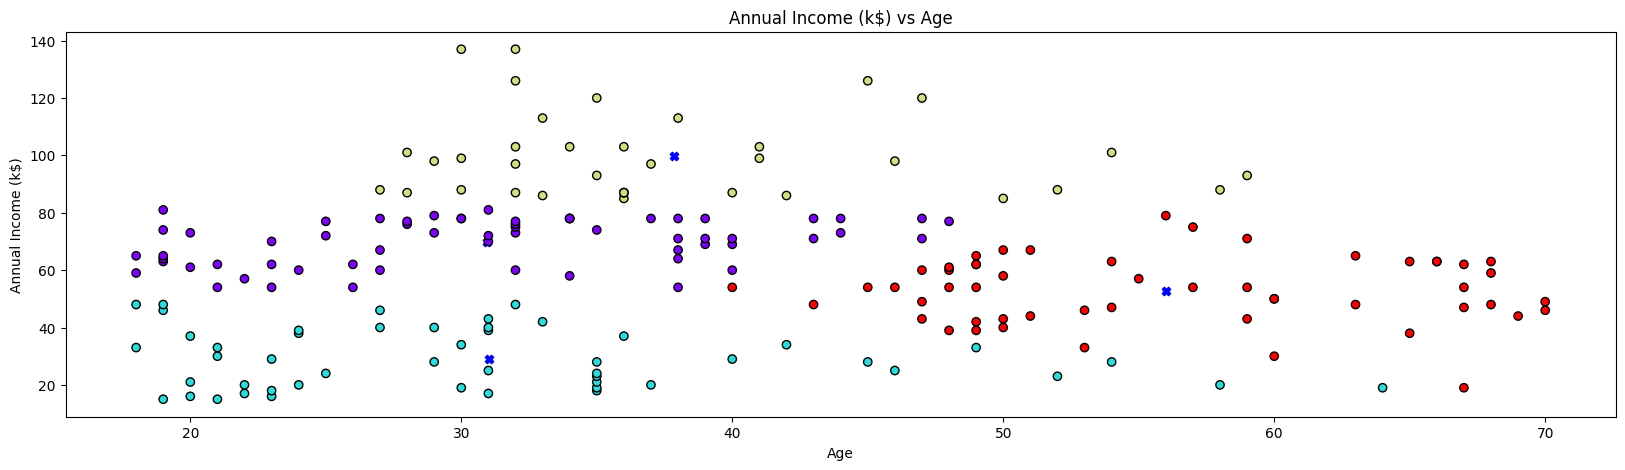

In [100]:
model = KMeans(n_clusters=4, max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels= model.labels_

plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker='X', color='b')
plt.scatter(x='Age', y='Annual Income (k$)', c=labels, cmap='rainbow', data=df1, edgecolors='black')
plt.title('Annual Income (k$) vs Age')
plt.xlabel('Age')
plt.ylabel('Annual Income (k$)')
plt.show()

Normalized Dataset

Elbow Method & Silhouette Score Method

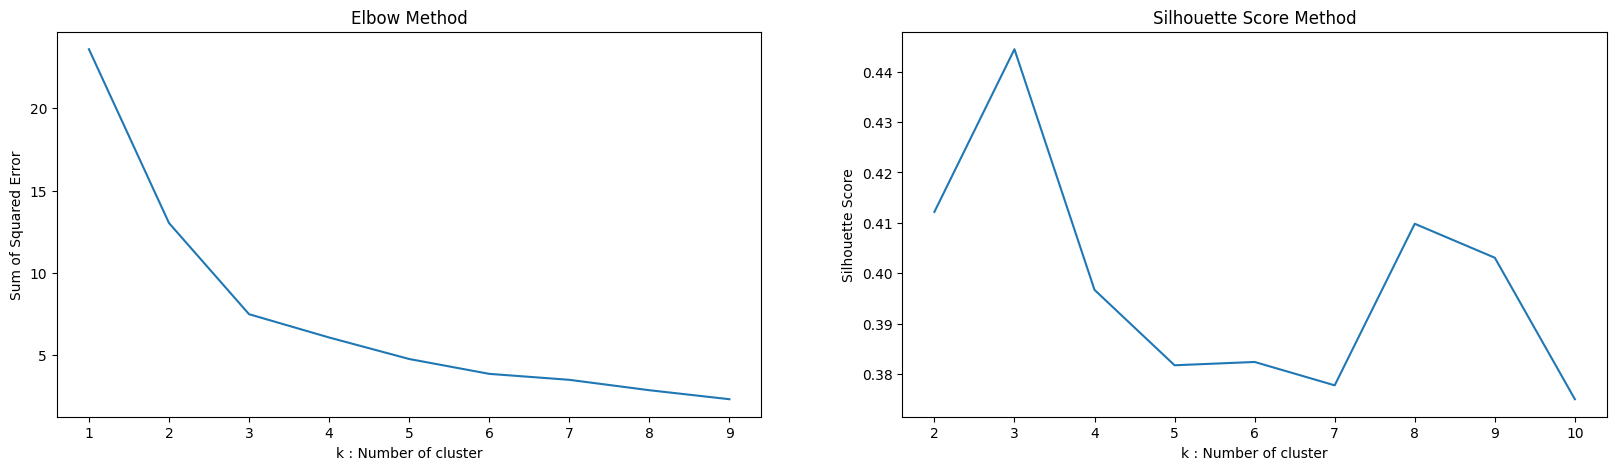

In [101]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

K: clusters = 6

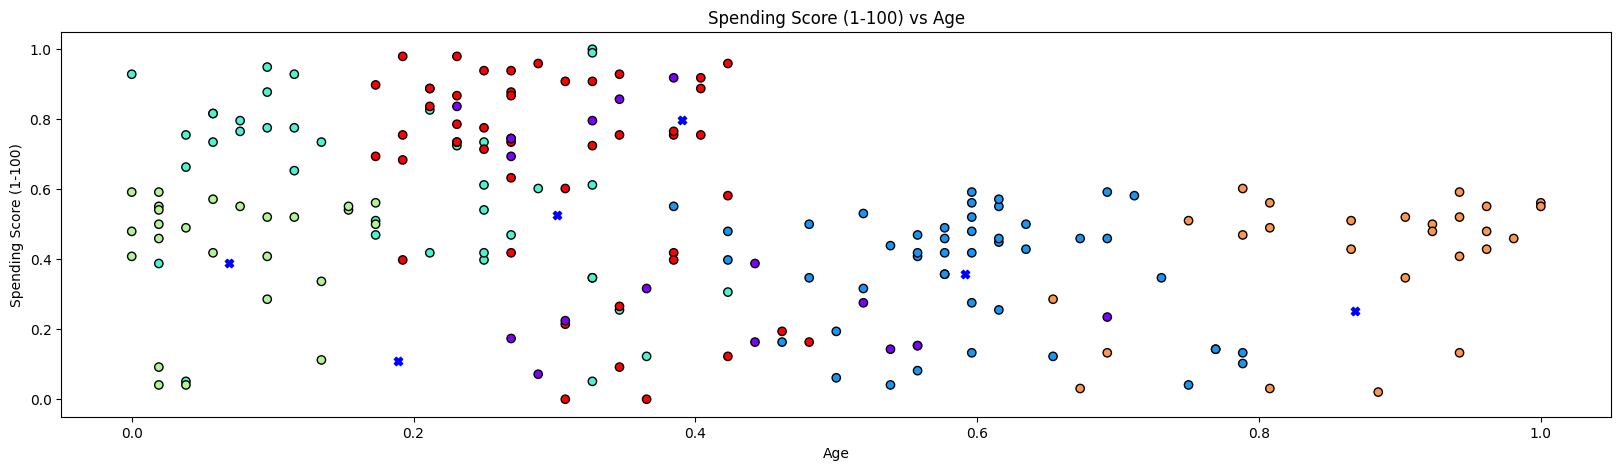

In [102]:
model = KMeans(n_clusters=6, max_iter= 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Age',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Age')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.show();

In [103]:
m1 = df1[['Annual Income (k$)','Spending Score (1-100)']].values #original dataset
m2 = df2[['Annual Income (k$)','Spending Score (1-100)']].values #normalized dataset

Original Dataset:

Elbow Method & Silhouette Score Method


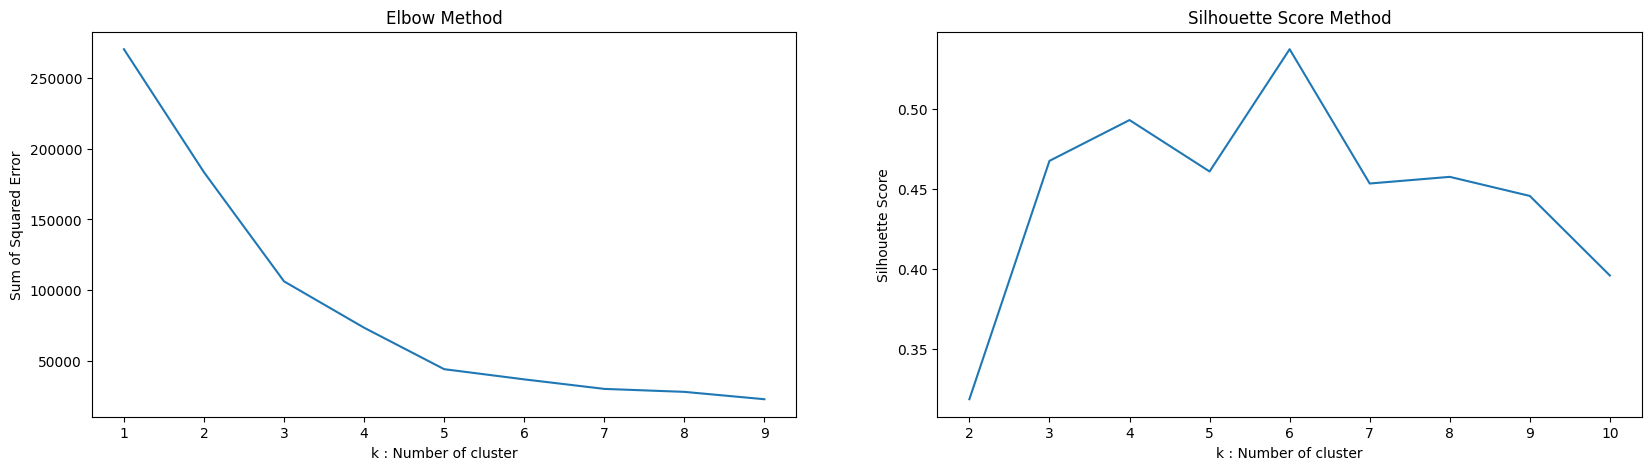

In [104]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

K: clusters = 5

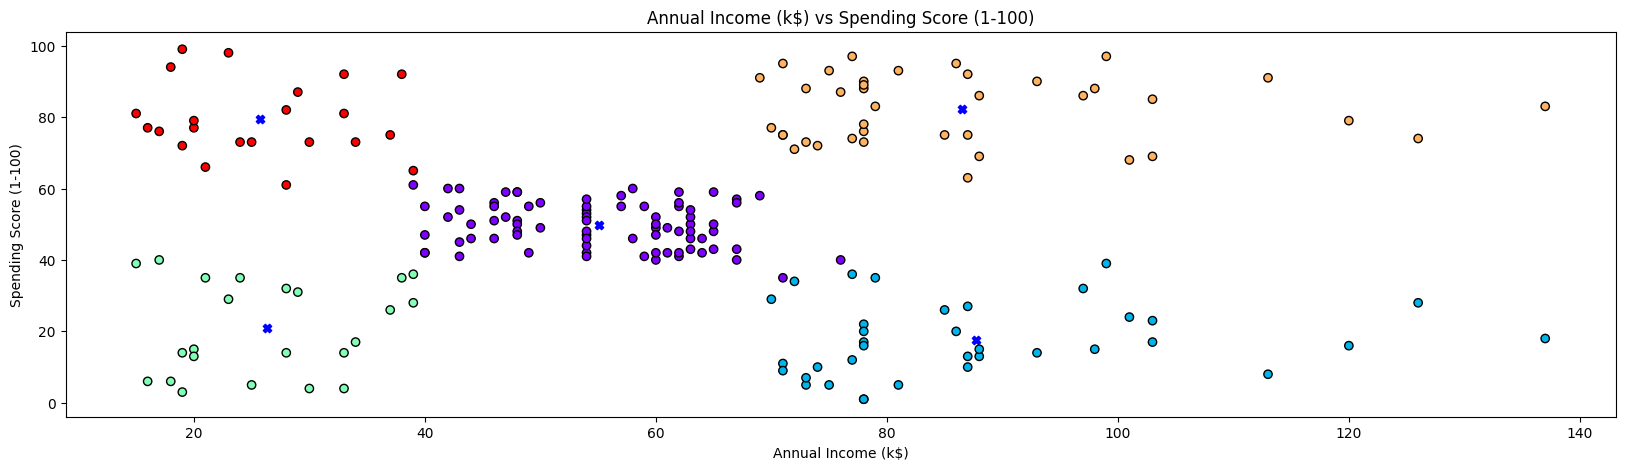

In [105]:
model = KMeans(n_clusters = 5, max_iter=1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize=(20,5))
plt.scatter(centroids[:,0], centroids[:,1], marker='X', color='b')
plt.scatter(x = 'Annual Income (k$)', y='Spending Score (1-100)', c=labels, cmap='rainbow', data=df1, edgecolors='black')
plt.title('Annual Income (k$) vs Spending Score (1-100)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()

Normalized Dataset:

Elbow Method & Silhouette Score Method

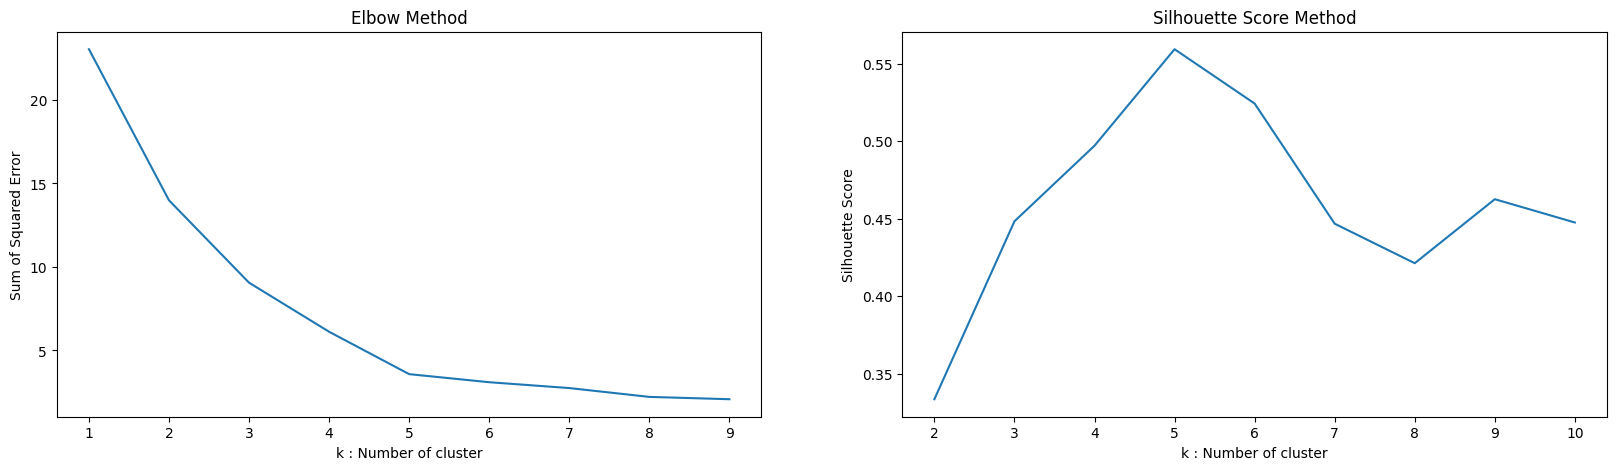

In [106]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k : Clusters = 5

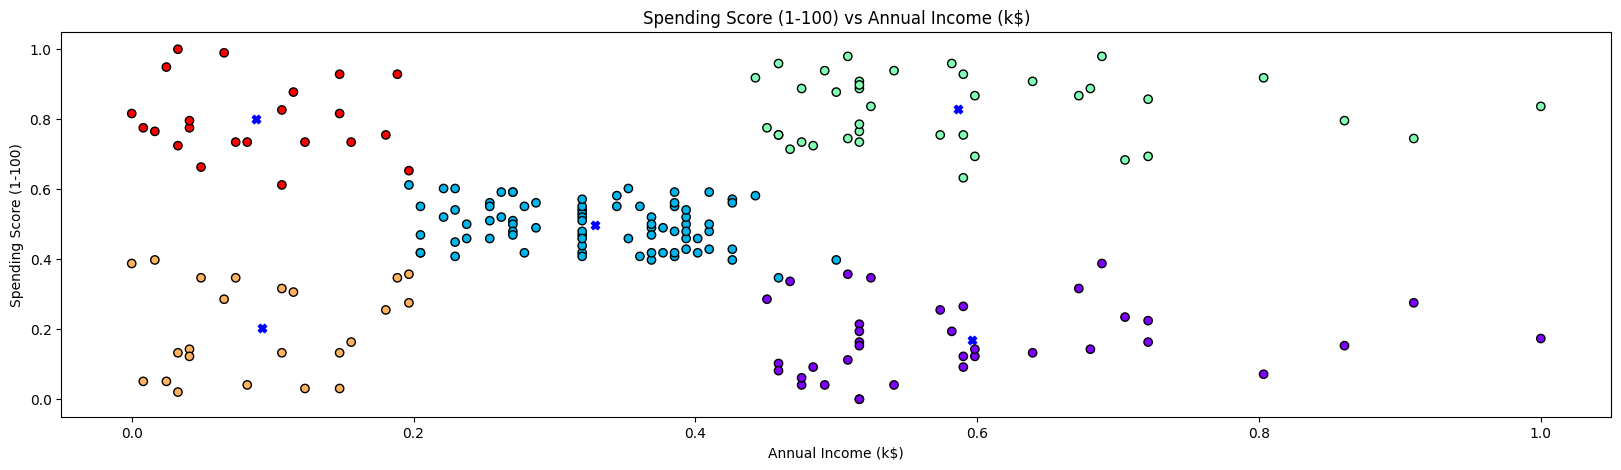

In [107]:
model = KMeans(n_clusters = 5,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

plt.figure(figsize = (20,5))
plt.scatter(centroids[:,0],centroids[:,1], marker = "X", color = 'b')
plt.scatter(x = 'Annual Income (k$)',y = 'Spending Score (1-100)',c = labels,cmap = 'rainbow',data = df2,edgecolor = 'black');
plt.title('Spending Score (1-100) vs Annual Income (k$)')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show();

In [108]:
m1 = df1[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Original Dataset
m2 = df2[['Age','Annual Income (k$)','Spending Score (1-100)']].values # Normalized Dataset

Original Dataset:

Elbow Method & Silhouette Score Method:

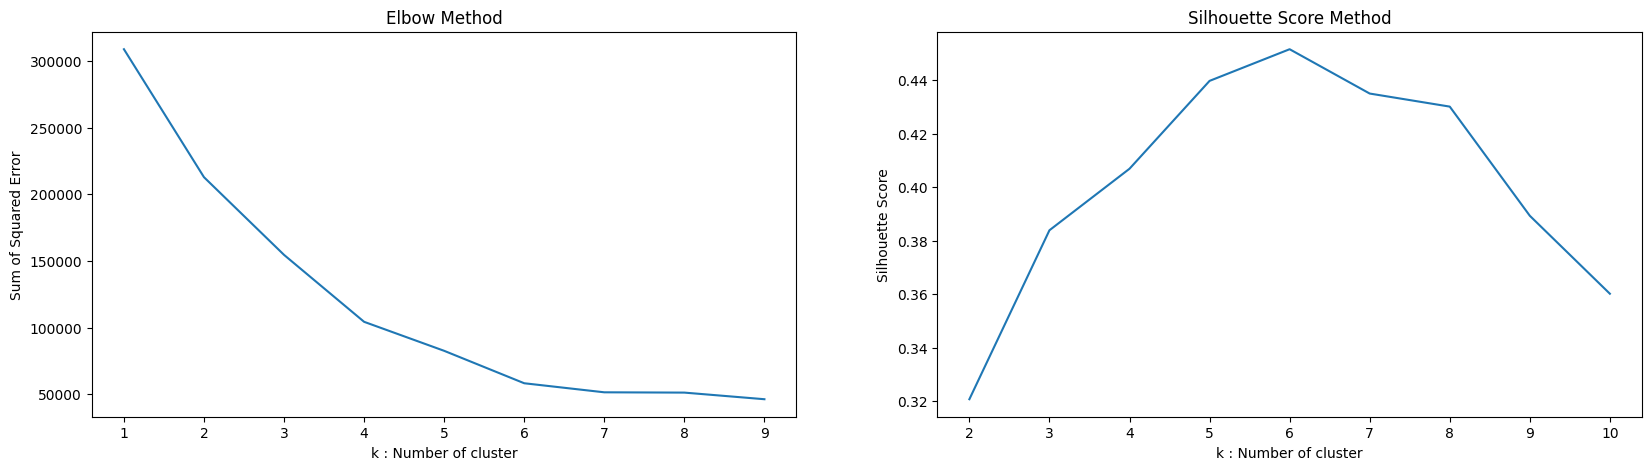

In [109]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m1)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m1)
    labels = kmeans.labels_
    sil.append(silhouette_score(m1, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k : Clusters = 6

/tmp/ipykernel_4323/1680557951.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


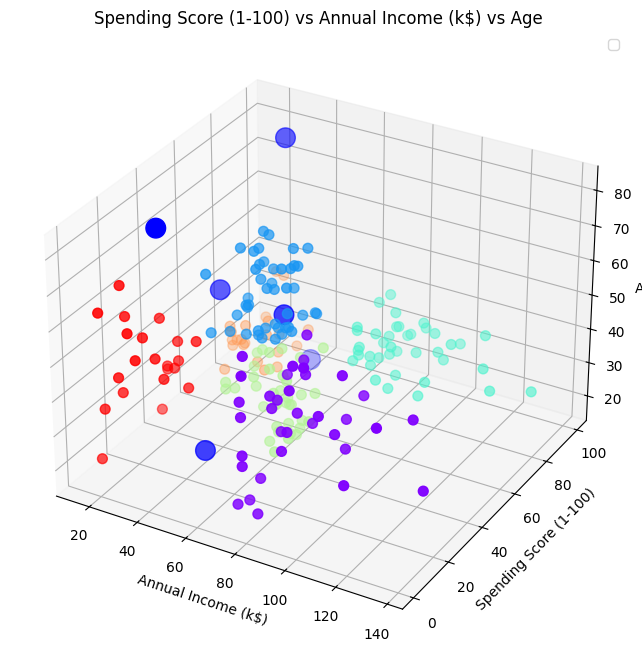

In [110]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m1)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x = np.array(df1['Annual Income (k$)'])
y = np.array(df1['Spending Score (1-100)'])
z = np.array(df1['Age'])
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2], s=200, color = 'b') # Removed marker="D" to use default circle
ax.scatter(x,y,z,c = labels, cmap='rainbow', s=50, edgecolor=None) # Removed edgecolor
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
ax.legend()
plt.show();

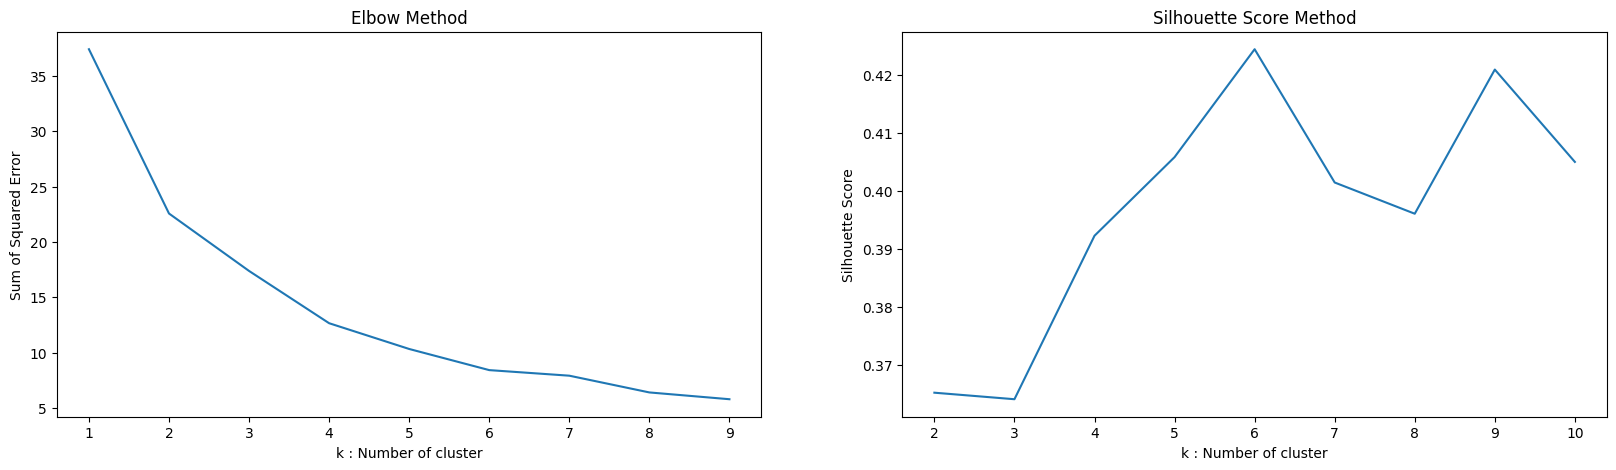

In [111]:
sse = {};sil = [];kmax = 10
fig = plt.subplots(nrows = 1, ncols = 2, figsize = (20,5))

# Elbow Method :
plt.subplot(1,2,1)
for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, max_iter=1000).fit(m2)
    sse[k] = kmeans.inertia_ # Inertia: Sum of distances of samples to their closest cluster center
sns.lineplot(x = list(sse.keys()), y = list(sse.values()));
plt.title('Elbow Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Sum of Squared Error")

# Silhouette Score Method
plt.subplot(1,2,2)
for k in range(2, kmax + 1):
    kmeans = KMeans(n_clusters = k).fit(m2)
    labels = kmeans.labels_
    sil.append(silhouette_score(m2, labels, metric = 'euclidean'))
sns.lineplot(x = range(2,kmax + 1), y = sil);
plt.title('Silhouette Score Method')
plt.xlabel("k : Number of cluster")
plt.ylabel("Silhouette Score")
plt.show()

k : Clusters = 6

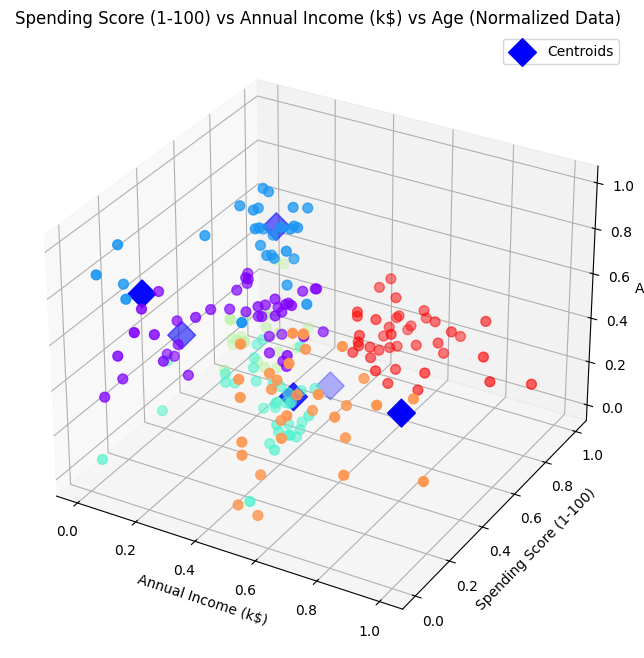

In [112]:
model = KMeans(n_clusters = 6,max_iter = 1000)
model.fit(m2)
cluster = model.cluster_centers_
centroids = np.array(cluster)
labels = model.labels_

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
x = m2[:, 1] # Annual Income (k$) is the second feature in m2
y = m2[:, 2] # Spending Score (1-100) is the third feature in m2
z = m2[:, 0] # Age is the first feature in m2
ax.scatter(centroids[:,0],centroids[:,1],centroids[:,2], marker = "D", s=200, color = 'b', label='Centroids')
ax.scatter(x,y,z,c = labels, cmap='rainbow', s=50, edgecolor=None)
plt.title('Spending Score (1-100) vs Annual Income (k$) vs Age (Normalized Data)')
ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
ax.legend()
plt.show();